In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import time

import astropy.units as u
import astropy.cosmology.units as cu
import astropy.constants as const

import raytrace

rng = np.random.default_rng()

In [2]:
colors = ['red', 'orangered','yellowgreen', 'royalblue', 'blueviolet']
cm_kpc = u.cm.to(u.kpc)
cm_kpc

3.2407792894443653e-22

In [3]:
with h5py.File("outputs/dm_proto.hdf5", "r") as f:
    halo_ids = list(f.keys())
halo_ids

['halo_11069985',
 'halo_12925051',
 'halo_15386300',
 'halo_18373384',
 'halo_2069291',
 'halo_252455',
 'halo_4152102',
 'halo_4356618',
 'halo_5160064']

In [68]:
halo_id = halo_ids[5][5:]
halo_id

'252455'

In [69]:
with h5py.File("outputs/dm_proto.hdf5", "r") as f:
    print(f.keys())
    halo = f['halo_' + halo_id]
    subs = halo['subhalos']
    print('\n'.join(list(subs.keys())))
    sub_ids = subs['id'][:]
    # sub_rads = subs['halfmassrad'][:]
    # sub_lums = subs['stellarphotometrics_v'][:]
    sub_sfr = subs['sfr'][:]
    # sub_coms = raytrace.unwrap(np.array([ subs['cm_x'], subs['cm_y'], subs['cm_z'] ]).T - com)

    star_pos = halo['trace']['star_pos'][:]
    directions = halo['trace']['direction'][:]
    
    trace = halo['trace']
    star_mass = trace['star_mass'][:]
    # star_mass = trace['star_id'][:]
    impact_id = trace['subhalo_id'][:, 0]

    impact_placement = np.searchsorted(sub_ids, impact_id)
    sub_mass = subs['massinhalfrad_stars'][:][impact_placement] * (1e10 * u.solMass).to(u.kg).value # kg
    sub_rads = subs['halfmassrad'][:][impact_placement]
    sub_lums = subs['stellarphotometrics_v'][:][impact_placement]
    # star_sfr = trace['star_id'][:][impact_placement] # Msun/yr
    
    impact = np.sqrt(raytrace.norm2(trace['subhalo_impact'][:, 0]))

    dm = np.sum(trace['dm_voronoi'][:], axis=1)
    print(impact.shape, dm.shape)


<KeysViewHDF5 ['halo_11069985', 'halo_12925051', 'halo_15386300', 'halo_18373384', 'halo_2069291', 'halo_252455', 'halo_4152102', 'halo_4356618', 'halo_5160064']>
bhmdot
cm_x
cm_y
cm_z
desc_sfid
desc_snap
gasmetallicity
gasmetallicityhalfrad
gasmetallicitymaxrad
gasmetallicitysfr
gasmetallicitysfrweighted
grnr
halfmassrad
halfmassrad_bhs
halfmassrad_dm
halfmassrad_gas
halfmassrad_stars
id
len
len_bhs
len_dm
len_gas
len_stars
mass
mass_bhs
mass_dm
mass_gas
mass_log_msun
mass_stars
massinhalfrad
massinhalfrad_bhs
massinhalfrad_dm
massinhalfrad_gas
massinhalfrad_stars
massinmaxrad
massinmaxrad_bhs
massinmaxrad_dm
massinmaxrad_gas
massinmaxrad_stars
massinrad
massinrad_bhs
massinrad_dm
massinrad_gas
massinrad_stars
parent
pos_x
pos_y
pos_z
primary_flag
prog_sfid
prog_snap
sfr
sfrinhalfrad
sfrinmaxrad
sfrinrad
snap
spin_x
spin_y
spin_z
starmetallicity
starmetallicityhalfrad
starmetallicitymaxrad
stellarphotometrics_b
stellarphotometrics_g
stellarphotometrics_i
stellarphotometrics_k
stellarp

Text(0.5, 0, 'sfr (Msun/yr)')

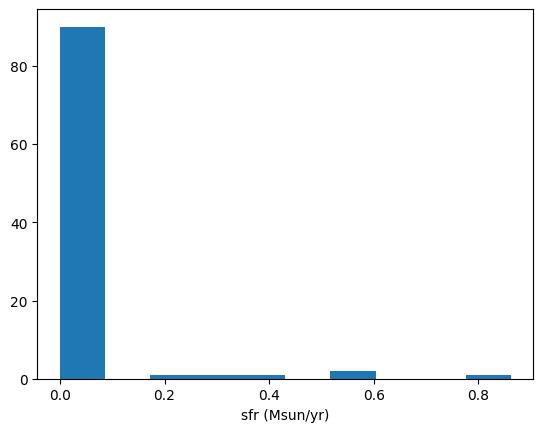

In [70]:
plt.hist(sub_sfr[sub_sfr<1])
plt.xlabel('sfr (Msun/yr)')

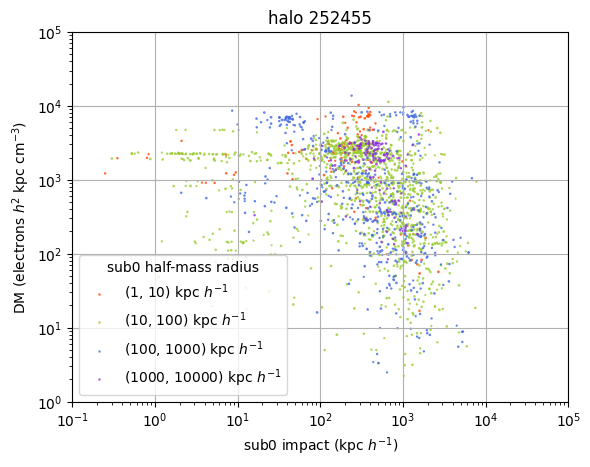

In [71]:
plt.title('halo ' + halo_id)

for i in np.arange(1, 5):
    select = (10**(i-1) < sub_rads) & (sub_rads < 10**i)
    # plt.hist(np.log10(impact[select]), bins=30)
    # plt.xlabel('impact distance (log10 ckpc)')
    # plt.show()
    plt.scatter(
        impact[select], 
        dm[select] * (cm_kpc**3) * 1000, 
        s=np.sqrt(star_mass[select]/1e36), alpha=0.8, lw=0, c=colors[i],
        label=f'({10.**(i-1):.0f}, {10**i:.0f}) kpc $h^{{-1}}$'
    )

    plt.gca().set_xscale('log')
    plt.gca().set_yscale('log')
    plt.xlim(1e-1, 1e5)
    plt.ylim(1e0, 1e5)
    plt.xlabel('sub0 impact (kpc $h^{-1}$)')
    plt.ylabel('DM (electrons $h^2$ kpc cm$^{-3}$)')
    plt.grid()
    leg = plt.legend(title='sub0 half-mass radius', loc='lower left')
plt.grid()
plt.savefig(f'outputs/plots/halo{halo_id}_dmimpact0.png')
plt.show()

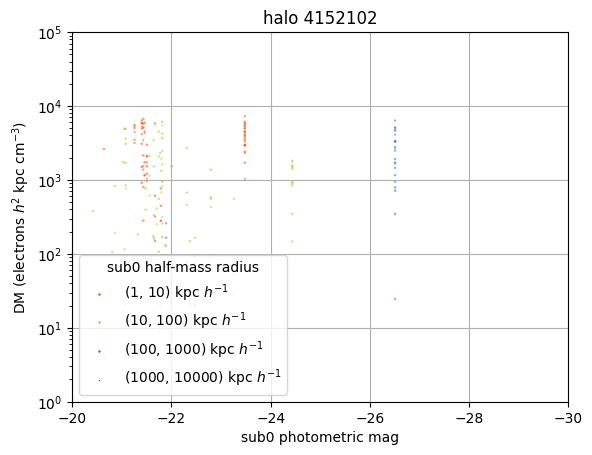

In [67]:
plt.title('halo ' + halo_id)

for i in np.arange(1, 5):
    select = (10**(i-1) < sub_rads) & (sub_rads < 10**i)
    plt.scatter(
        sub_lums[select], 
        dm[select] * (cm_kpc**3) * 1000, 
        s=np.sqrt(star_mass[select]/1e36), alpha=0.5, lw=0, c=colors[i],
        label=f'({10.**(i-1):.0f}, {10**i:.0f}) kpc $h^{{-1}}$'
    )
    # print(sub_lums)
plt.xlabel('sub0 photometric mag')
# plt.gca().set_xscale('log')
plt.gca().set_yscale('log')
plt.ylim(1e0, 1e5)
plt.xlim(-20, -30)
plt.ylabel('DM (electrons $h^2$ kpc cm$^{-3}$)')
leg = plt.legend(title='sub0 half-mass radius', loc='lower left')
for lh in leg.legend_handles:
    lh.set_alpha(1)
plt.grid()
plt.savefig(f'outputs/plots/halo{halo_id}_dmlum0.png')
plt.show()


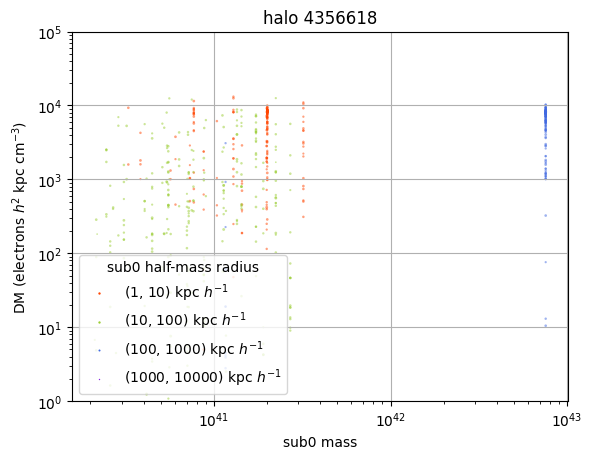

In [57]:
plt.title('halo ' + halo_id)

for i in np.arange(1, 5):
    select = (10**(i-1) < sub_rads) & (sub_rads < 10**i)
    plt.scatter(
        sub_mass[select], 
        dm[select] * (cm_kpc**3) * 1000, 
        s=np.sqrt(star_mass[select]/1e36), alpha=0.5, lw=0, c=colors[i],
        label=f'({10.**(i-1):.0f}, {10**i:.0f}) kpc $h^{{-1}}$'
    )
    # print(sub_lums)
plt.xlabel('sub0 mass')
plt.gca().set_xscale('log')
plt.gca().set_yscale('log')
plt.ylim(1e0, 1e5)
# plt.xlim(-30, -20)
plt.ylabel('DM (electrons $h^2$ kpc cm$^{-3}$)')
leg = plt.legend(title='sub0 half-mass radius', loc='lower left')
for lh in leg.legend_handles:
    lh.set_alpha(1)
plt.grid()
plt.savefig(f'outputs/plots/halo{halo_id}_dmmass0.png')
plt.show()


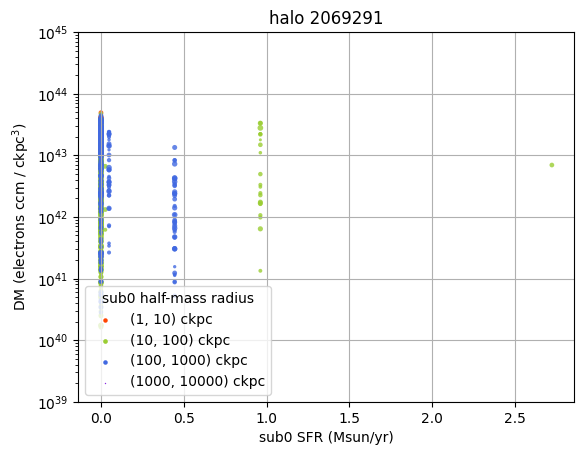

In [36]:
plt.title('halo ' + halo_id)

for i in np.arange(1, 5):
    select = (10**(i-1) < sub_rads) & (sub_rads < 10**i)
    plt.scatter(
        sub_sfr[select], 
        dm[select] * cm_kpc, 
        s=star_mass[select]/1e36, alpha=0.8, lw=0, c=colors[i],
        label=f'({10.**(i-1):.0f}, {10**i:.0f}) ckpc'
    )
    # print(sub_lums)
plt.xlabel('sub0 SFR (Msun/yr)')
# plt.gca().set_xscale('log')
plt.gca().set_yscale('log')
plt.ylim(1e39, 1e45)
# plt.xlim(-30, -20)
plt.ylabel('DM (electrons ccm / ckpc$^3$)')
leg = plt.legend(title='sub0 half-mass radius', loc='lower left')
for lh in leg.legend_handles:
    lh.set_alpha(1)
plt.grid()
plt.savefig(f'outputs/plots/halo{halo_id}_dmmass0.png')
plt.show()


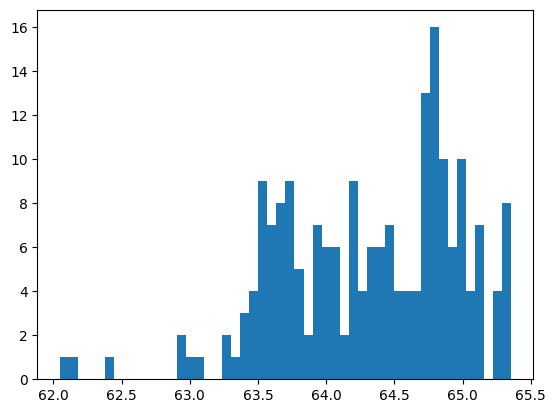

In [162]:
plt.hist(np.log10(dm), bins=50)
plt.show()

(array([  2.,   8.,  34., 132., 196., 366., 460., 374., 298., 130.]),
 array([6.24907566, 6.3194723 , 6.38986894, 6.46026558, 6.53066223,
        6.60105887, 6.67145551, 6.74185215, 6.81224879, 6.88264543,
        6.95304207]),
 <BarContainer object of 10 artists>)

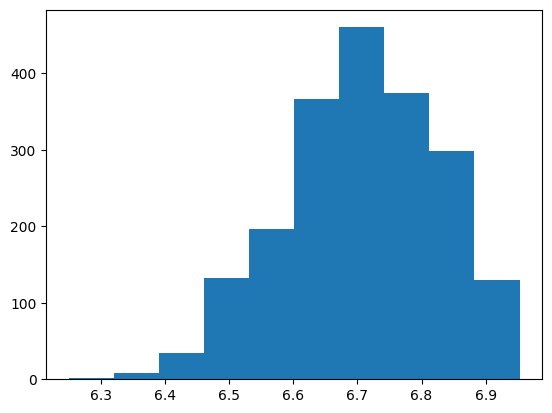

In [20]:
plt.hist(np.log10(star_mass*5e-31))

In [87]:
# sampling distribution
# currently: pick random star particle; later reweight by SFR
# also: randomly pick subhalo, then pick star particle from subhalo; better mass binning
# throw away slightlines where primary subhalo != originator subhalo

In [42]:
# bin by subhalo mass / virial radius
# get impact geometrically at initialization
# some scatter is OK
# plot: DM total vs primary stellar mass, in halo mass bins;
# do separately for galaxies with bright secondaries vs systems with no bright secondaries
# plot: luminosity of primary vs luminosity of secondary, with DM as color
# plot: halo mass vs DM, vs impact parameter / virial radius; focus on low-mass end of TNG-cluster, feedback is more important?
# plot: 
# peculiar velocity related to outskirts vs inskirts
# galaxy cluster stats
# excess DM outside virial radius? important for low halo mass / feedback
# Paper Titles: “more DM beyond 1 R_vir? Yes!”
# “It doesn’t matter whether you see the secondary galaxy”
# 

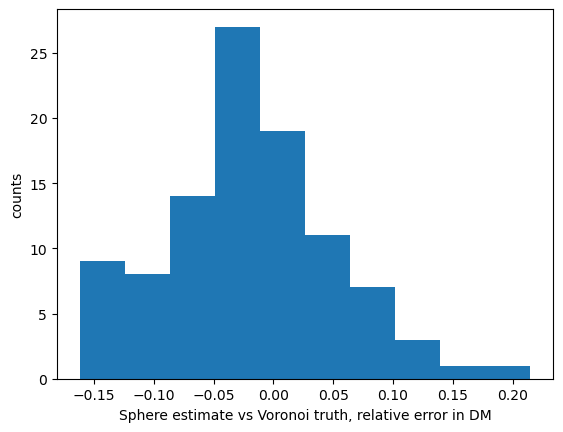

In [108]:
with h5py.File("outputs/dm_proto.hdf5", "r") as f:
    plt.hist(np.array(f[group_id]['DMSphere'])/np.array(f[group_id]['DM']) - 1)
    plt.xlabel('Sphere estimate vs Voronoi truth, relative error in DM')
    plt.ylabel('counts')

In [118]:
import importlib
importlib.reload(raytrace)

<module 'raytrace' from '/home/xingyzt/Documents/halo/raytrace.py'>